# Transfer Learning MobileNetV2(Emotion Detection)

In [1]:
# 1.Install & Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os


In [2]:
#2. Dataset Load (Assuming Folder Structure)
from google.colab import files
uploaded = files.upload()  # Choose your .zip file here


Saving Emotion Detection.zip to Emotion Detection.zip


In [3]:
import zipfile
import os

zip_path = "Emotion Detection.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("emotion_dataset")

# Set dataset paths
train_path = "emotion_dataset/DataSet for Emotion Detection/train_data"
test_path = "emotion_dataset/DataSet for Emotion Detection/test_data"
predict_path = "emotion_dataset/DataSet for Emotion Detection/single_prediction"


In [4]:
# 3. Data Preprocessing
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [5]:
# 4. Load Pretrained Model (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = True  # Unfreeze all layers


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# 5. Add Custom Layers using Functional API
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(train_generator.num_classes, activation='softmax')(x)

# Create the new model
model = Model(inputs=base_model.input, outputs=outputs)


In [7]:
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [8]:
# 6. Train the Model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50,
    callbacks=[early_stop]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 421s 410ms/step - accuracy: 0.2018 - loss: 2.0974 - val_accuracy: 0.2576 - val_loss: 1.8034
Epoch 2/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 342s 380ms/step - accuracy: 0.3062 - loss: 1.7309 - val_accuracy: 0.3932 - val_loss: 1.6002
Epoch 3/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 344s 381ms/step - accuracy: 0.3866 - loss: 1.5914 - val_accuracy: 0.4338 - val_loss: 1.4826
Epoch 4/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 346s 384ms/step - accuracy: 0.4248 - loss: 1.4910 - val_accuracy: 0.4701 - val_loss: 1.3967
Epoch 5/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 348s 386ms/step - accuracy: 0.4696 - loss: 1.3916 - val_accuracy: 0.4775 - val_loss: 1.3729
Epoch 6/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 352s 391ms/step - accuracy: 0.4893 - loss: 1.3426 - val_accuracy: 0.5017 - val_loss: 1.3039
Epoch 7/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 351s 389ms/step - accuracy: 0.5016 - loss: 1.2949 - val_accuracy: 0.5232 - val_loss: 1.2495
Epoch 8/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 350s 389ms/step - accuracy: 0.5209 -

In [24]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Step 1: Path to your image
img_path = r"emotion_dataset/DataSet for Emotion Detection/single_prediction/surprise.jpg"

# Step 2: Load and preprocess image
img = image.load_img(img_path, target_size=(img_size, img_size))  # same size as training
img_array = image.img_to_array(img) / 255.0  # normalize
img_array = np.expand_dims(img_array, axis=0)  # model expects batch shape

# Step 3: Make prediction
prediction = model.predict(img_array)
predicted_class_index = np.argmax(prediction)

# Step 4: Get class label
class_labels = list(train_generator.class_indices.keys())
predicted_label = class_labels[predicted_class_index]

# Step 5: Output
print(f"✅ Predicted Emotion: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
✅ Predicted Emotion: surprise


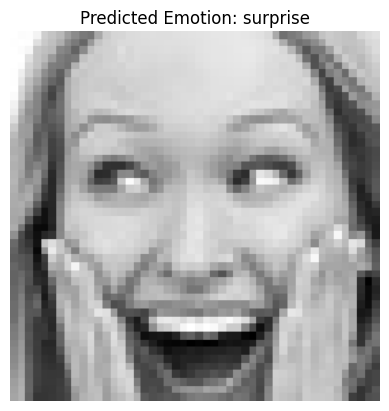

In [25]:
# Show the Image with Prediction
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Predicted Emotion: {predicted_label}")
plt.axis('off')
plt.show()


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


In [12]:
# Predict on Test Set
# True labels
y_true = test_generator.classes

# Predicted probabilities
y_pred_probs = model.predict(test_generator)

# Convert to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Class labels (e.g. ['angry', 'happy', 'sad', ...])
class_labels = list(test_generator.class_indices.keys())


221/221 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step


In [13]:
# Classification report (includes precision, recall, f1-score, accuracy)
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
print("🔍 Classification Report:\n")
print(report)


🔍 Classification Report:

              precision    recall  f1-score   support

       angry     0.1374    0.1323    0.1348       960
     disgust     0.0000    0.0000    0.0000       111
        fear     0.1373    0.1100    0.1221      1018
       happy     0.2508    0.2427    0.2467      1825
     neutral     0.1573    0.1982    0.1754      1216
         sad     0.1575    0.1554    0.1564      1139
    surprise     0.1145    0.1242    0.1191       797

    accuracy                         0.1697      7066
   macro avg     0.1364    0.1376    0.1364      7066
weighted avg     0.1686    0.1697    0.1685      7066



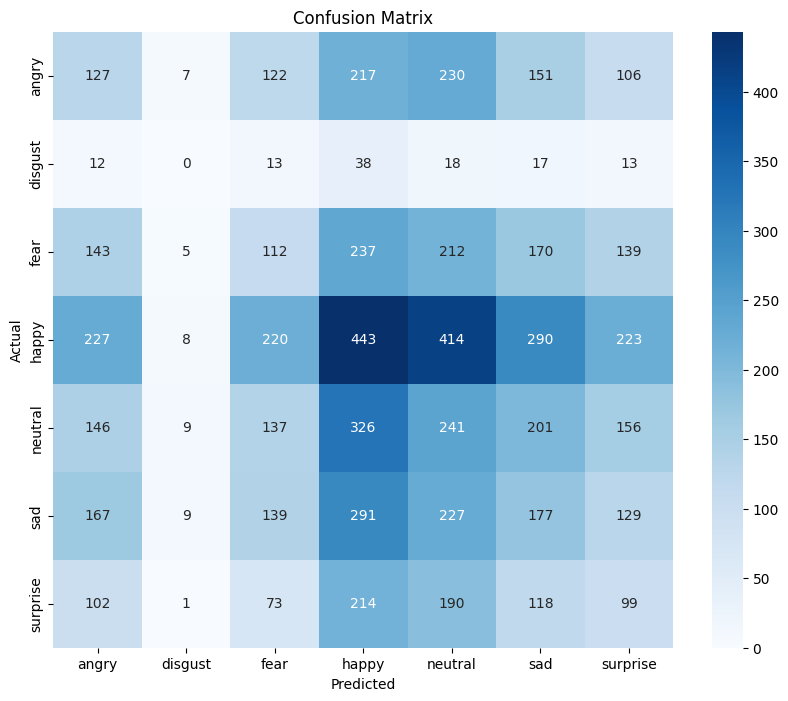

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


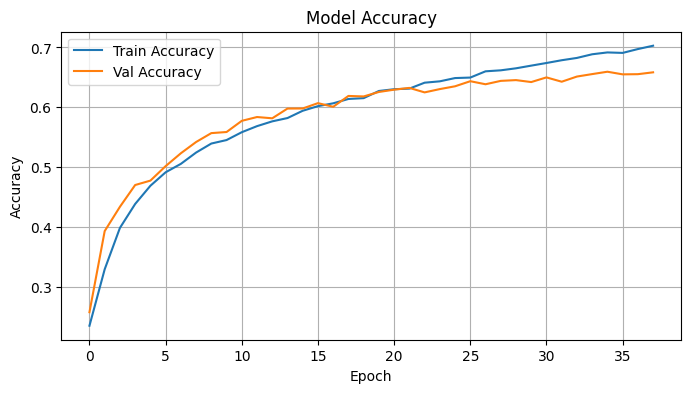

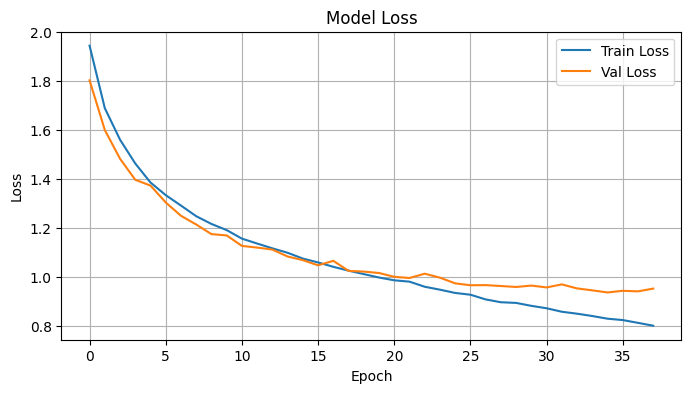

In [15]:
# Plot accuracy
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [26]:
model.save('Uzair-MobileNetV2-Emotion_model.h5')

In [27]:
from google.colab import files
files.download('Uzair-MobileNetV2-Emotion_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>